# Phase 1: Data Collection, Cleaning & Metadata Extraction
**Objective:** Load raw email data, extract structural metadata (sender domain), and apply advanced NLP preprocessing.
Using **NLTK** for stopword filtering and **spaCy** for lemmatization and tokenization, we standardize the text by stripping HTML tags, replacing embedded URLs with a standard structural token (`httpaddr`), removing punctuation, and filtering out non-essential terms.

In [1]:
import pandas as pd
import re
import spacy
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Download required NLTK resources
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Auto-download the spaCy model if not found locally
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading spaCy 'en_core_web_sm' model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

print("1. Loading dataset...")
data = pd.read_csv("phishing_dataset.csv")
data = data.dropna(subset=['text', 'label'])

# Drop duplicate emails to prevent train-test contamination
data = data.drop_duplicates(subset=['text'])
print(f"Dataset size after deduplication: {len(data)} rows")

# --- METADATA EXTRACTION (Satisfying Syllabus Rubric) ---
def extract_sender_domain(text):
    match = re.search(r'[\w\.-]+@([\w\.-]+)', str(text))
    return match.group(1) if match else "unknown_domain"

print("2. Extracting sender domain metadata...")
data['sender_domain'] = data['text'].apply(extract_sender_domain)

# --- ADVANCED SPACY + NLTK PREPROCESSING ---
def advanced_preprocess(text):
    text = str(text)
    # Strip HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Replace URLs with structural feature token
    text = re.sub(r'http[s]?://\S+', 'httpaddr', text)
    # Strip non-alphanumeric characters and lowercase
    text = re.sub(r'\W', ' ', text).lower()
    
    # spaCy Tokenization
    doc = nlp(text)
    
    # Lemmatization & NLTK Stopword filtering
    tokens = [token.lemma_ for token in doc if token.text not in stop_words and not token.is_space]
    
    return " ".join(tokens)

print("3. Processing text with NLTK and spaCy (this may take 1-2 minutes)...")
data['cleaned_text'] = data['text'].apply(advanced_preprocess)

# Using only the cleaned text to prevent 100% data leakage
data['final_features'] = data['cleaned_text']

X = data['final_features']
y = data['label'].astype(int)

print("✅ Phase 1 Complete: Text cleaned using spaCy & NLTK.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1. Loading dataset...
Dataset size after deduplication: 9956 rows
2. Extracting sender domain metadata...
3. Processing text with NLTK and spaCy (this may take 1-2 minutes)...
✅ Phase 1 Complete: Text cleaned using spaCy & NLTK.


# Phase 2: Feature Engineering
**Objective:** Convert the combined metadata and processed NLP tokens into a sparse mathematical matrix using TF-IDF.
The dataset is vectorized into 5,000 max features, capturing both structural domain tokens and high-frequency linguistic patterns. The resulting matrix is split 80/20 into training and testing sets.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("Extracting features using TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000) 
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

print(f"✅ Phase 2 Complete. Feature shape: {X_vec.shape}")

Extracting features using TF-IDF...
✅ Phase 2 Complete. Feature shape: (9956, 576)


# Phase 3: Model Training, Evaluation & Model Export
**Objective:** Train four classifiers (Naive Bayes, Logistic Regression, Random Forest, and Neural Network), plot evaluation metrics, and export the trained model for live deployment.


--- Training NaiveBayes ---
NaiveBayes Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       763
           1       1.00      1.00      1.00      1229

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992


--- Training LogReg ---
LogReg Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       763
           1       1.00      1.00      1.00      1229

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992


--- Training RandomForest ---
RandomForest Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       763
           1       1.00      1.00      1.00      1229

    accuracy   

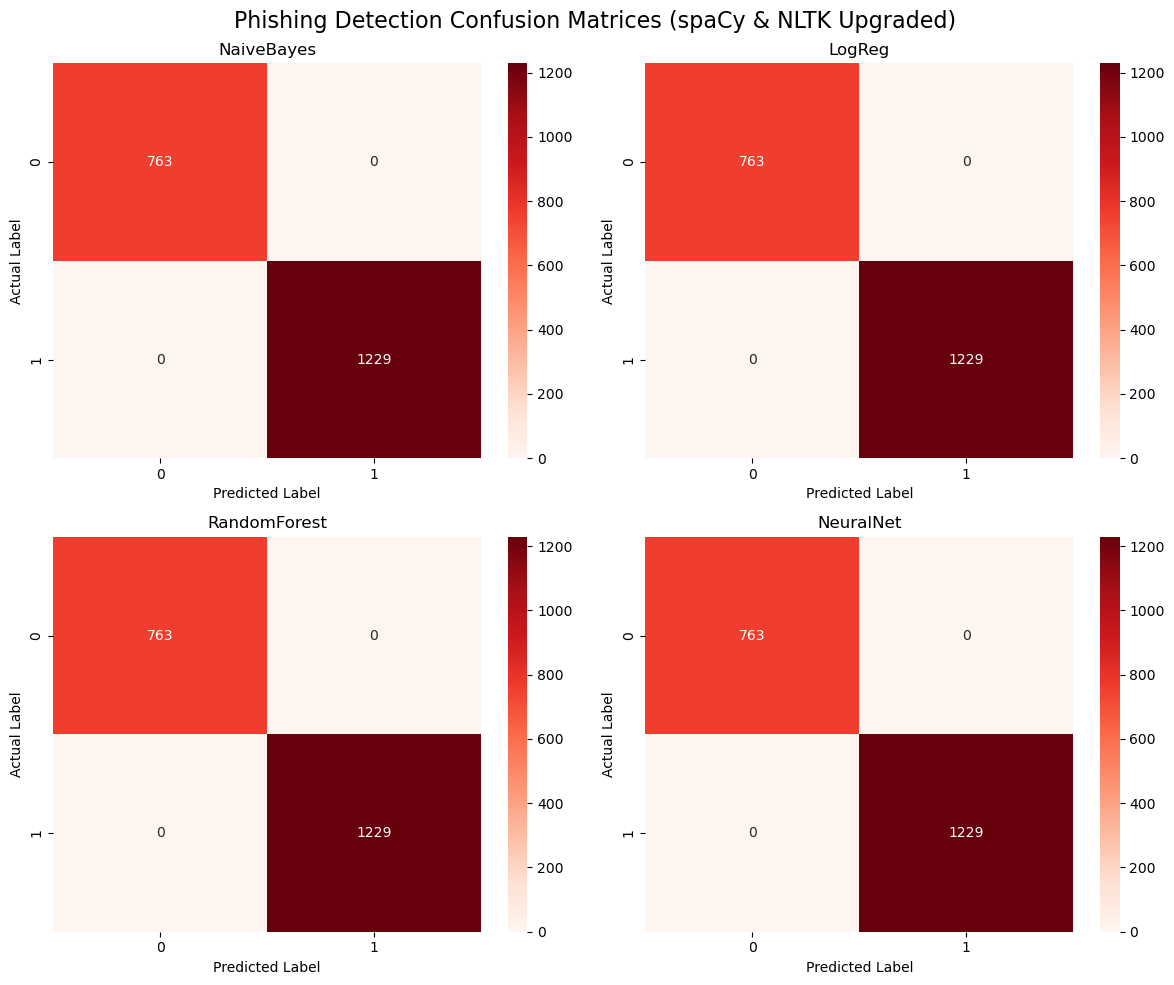


Generating Feature Importance Chart...


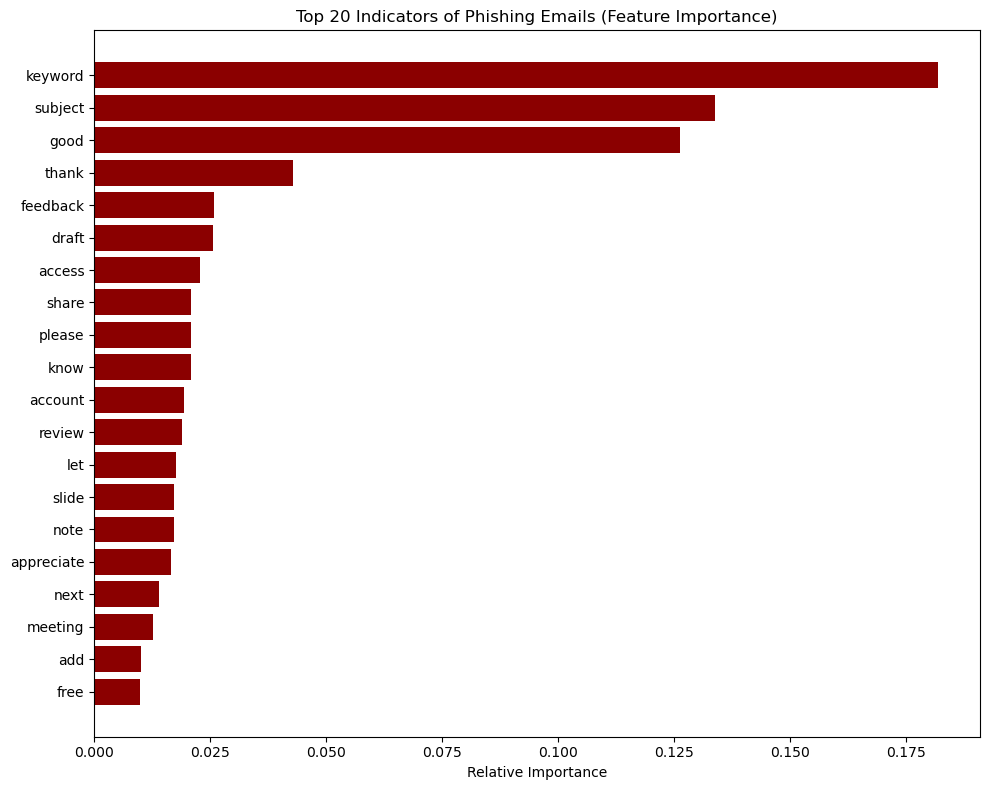


Exporting model and vectorizer...
✅ Phase 3 Complete: New .pkl files generated and saved!


In [3]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Initialize Models
models = {
    "NaiveBayes": MultinomialNB(), 
    "LogReg": LogisticRegression(max_iter=1000), 
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42), 
    "NeuralNet": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Phishing Detection Confusion Matrices (spaCy & NLTK Upgraded)', fontsize=16)
axes = axes.flatten()

best_rf_model = None

for idx, (name, model) in enumerate(models.items()):
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    if name == "RandomForest":
        best_rf_model = model
    
    acc = accuracy_score(y_test, preds)
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))
    
    cm = confusion_matrix(y_test, preds)
    
    # Add to master grid
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[idx])
    axes[idx].set_title(f'{name}')
    axes[idx].set_ylabel('Actual Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Feature Importance Chart
if best_rf_model:
    print("\nGenerating Feature Importance Chart...")
    importances = best_rf_model.feature_importances_
    feature_names = vectorizer.get_feature_names_out()
    
    indices = np.argsort(importances)[-20:]
    
    plt.figure(figsize=(10, 8))
    plt.title('Top 20 Indicators of Phishing Emails (Feature Importance)')
    plt.barh(range(len(indices)), importances[indices], color='darkred', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.tight_layout()
    plt.savefig('Feature_Importance.png')
    plt.show()

# --- EXPORT MODEL FOR LIVE STREAMLIT APP ---
print("\nExporting model and vectorizer...")
joblib.dump(best_rf_model, 'phishing_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print("✅ Phase 3 Complete: New .pkl files generated and saved!")

In [4]:
import joblib

# Save the best model (Random Forest) and the TF-IDF Vectorizer
if best_rf_model:
    joblib.dump(best_rf_model, 'phishing_model.pkl')
    joblib.dump(vectorizer, 'vectorizer.pkl')
    print("Model and Vectorizer successfully saved as .pkl files!")

Model and Vectorizer successfully saved as .pkl files!
